In [132]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [133]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [134]:
api_wrapper_wikipedia=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)

In [135]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")



In [136]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily=TavilySearchResults()

In [137]:
tavily.invoke("what is the recent war news")

[{'title': 'World Conflicts News | Latest News - NewsNow',
  'url': 'https://www.newsnow.com/us/World/War+and+Terrorism/World+Conflicts',
  'content': 'Recent developments include continued fighting in eastern Ukraine, with tens of thousands of casualties reported in 2024. The Israel-Hamas war that began in October 2023 has resulted in thousands of deaths in Gaza and Israel, with ongoing concerns about a wider regional conflict. In Africa, the Sudanese civil war has caused over 100,000 casualties since its outbreak in 2023, while insurgencies in the Sahel continue to destabilize countries like Burkina Faso, Mali, and Niger. [...] NewsNow\n\n# World Conflicts  Share\n\nShare\n\n## Latest\n\n#### About our World Conflicts news\n\nLatest news on world conflicts, providing comprehensive coverage of ongoing wars, territorial disputes, ethnic tensions, peacekeeping efforts, and diplomatic negotiations in hotspots across Africa, Asia, Europe, and the Middle East.\n\nThe world continues to gra

In [138]:
tools=[arxiv,wiki,tavily]

In [139]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")

In [140]:
llm.invoke("what is ml")

AIMessage(content='<think>\nOkay, the user asked "what is ml". Let me start by breaking that down. ML usually stands for Machine Learning. But maybe they\'re referring to something else in their context. However, given the common usage, Machine Learning is the most probable answer.\n\nFirst, I should define Machine Learning simply. It\'s a subset of artificial intelligence that allows systems to learn from data. But how do I explain it in a way that\'s easy to understand? Maybe use an example. Like teaching a computer to recognize cats in pictures by showing it many examples.\n\nNext, I should outline the key concepts. Supervised learning, unsupervised learning, reinforcement learning. These are the main categories. Give a brief description of each. Supervised uses labeled data, like predicting house prices based on features. Unsupervised finds patterns without labels, like clustering customers into groups. Reinforcement learning is about learning through rewards, like a robot navigati

In [141]:
llm_with_tools=llm.bind_tools(tools=tools)

In [142]:
llm_with_tools.invoke("what is attention all you need")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is attention all you need." Hmm, I need to figure out what they\'re referring to. The phrase "attention all you need" sounds familiar. Oh, right! It\'s the title of a seminal paper in the field of machine learning, specifically about the Transformer model. The paper introduced the concept of self-attention mechanisms, which revolutionized natural language processing.\n\nSo, the user probably wants an explanation of this paper or the concept. Let me check if they want a summary, the key contributions, or something else. Since the query is straightforward, they might just need a brief overview. The tools available include arxiv, wikipedia, and tavily_search. \n\nThe arxiv function is for academic papers, so using that would be appropriate here because the paper is on arXiv. The search query should be the title of the paper. Let me make sure the paper is indeed titled "Attention Is All You Need."

In [143]:
llm_with_tools.invoke("what is recent new on stock market")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on the stock market. I need to figure out which tool to use here. Let me check the available functions.\n\nThe tools provided are arxiv, wikipedia, and tavily_search_results_json. The arxiv is for scientific papers, which doesn\'t seem relevant here. Wikipedia is for general knowledge and historical information, but the user wants recent news. Tavily_search_results_json is described as a search engine for current events, which fits the query best. \n\nSo, I should use tavily_search_results_json with the query "recent stock market news". That should get the latest information. Let me make sure the parameters are correct. The function requires a query string, and I\'m providing that. Alright, that\'s the right choice.\n', 'tool_calls': [{'id': 'e2eksegrd', 'function': {'arguments': '{"query":"recent stock market news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, res

In [144]:
llm_with_tools.invoke("hey my name is manoj")

AIMessage(content='Hello Manoj! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "hey my name is manoj." Let me think about how to respond. First, I need to acknowledge his introduction. Since he provided his name, I should use it in the response to make it personal. The user might be testing if I can remember his name for future interactions, so I should make sure to address him by name.\n\nNow, considering the tools available, there\'s no immediate need to call any functions here. The user didn\'t ask a question that requires looking up information on Wikipedia, Arxiv, or a search engine. My response should be friendly and open-ended to encourage further conversation. Maybe something like, "Hello Manoj! How can I assist you today?" That way, I\'m being polite and inviting him to ask for help with whatever he needs. I don\'t see any hidden queries or requests in his message, so a simple, cheerful reply should be appropriate.\n'}, response_met

In [145]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [146]:
class State(TypedDict):
    messages:list[Annotated[list[AnyMessage],add_messages]]
    

In [147]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from IPython.display import Image,display

In [148]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [149]:
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

In [150]:
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition,
)
builder.add_edge("tools",END)

In [151]:
graph=builder.compile()

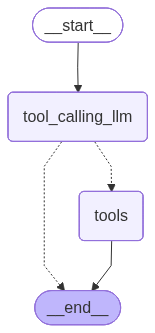

In [152]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [155]:
messages=graph.invoke({"messages":"my name is manoj"})
for m in messages["messages"]:
    m.pretty_print()

================================== Ai Message ==================================

Hello, Manoj! How can I assist you today?


In [156]:
messages=graph.invoke({"messages":"recent news on war"})
for m in messages["messages"]:
    m.pretty_print()

================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Russia-Ukraine war updates from April 19, 2024 - CNBC", "url": "https://www.cnbc.com/2024/04/19/ukraine-war-live-updates-latest-news-on-russia-and-the-war-in-ukraine.html", "content": "\"For the first time, the anti-aircraft missile units of the Air Force, in cooperation with the Main Directorate of Intelligence of the Ministry of Defense of Ukraine, destroyed the Tu-22M3 long-range strategic bomber - the carrier of Kh-22 cruise missiles, which Russian terrorists use to attack peaceful Ukrainian cities,\" Oleschuk said via Telegram, according to a Google translation.\n\n\"During today's attack, two such missiles were destroyed for the first time. Ukraine needs more means, more missiles, in order to better protect the frontline territories from Russian terrorism,\" he added.\n\nCNBC could not independently verify the report. [...] In a post shared via social med

In [157]:
messages=graph.invoke({"messages":"lora and qlora research papers"})
for m in messages["messages"]:
    m.pretty_print()

================================= Tool Message =================================
Name: arxiv

Published: 2025-10-12
Title: LoRA-FAIR: Federated LoRA Fine-Tuning with Aggregation and Initialization Refinement
Authors: Jieming Bian, Lei Wang, Letian Zhang, Jie Xu
Summary: Foundation models (FMs) achieve strong performance across diverse tasks with task-specific fine-tuning, yet full parameter fine-tuning is often computationally prohibitive for large models. Parameter-efficient fine-tuning (PEFT) methods like Low-Rank Adaptation (LoRA) reduce this cost by introducing low-rank matrices for 


In [158]:
messages=graph.invoke({"messages":"my name is manoj, what is attention all you need and give me recnet war news"})
for m in messages["messages"]:
    m.pretty_print()

================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Ukraine War | Latest News & Updates - BBC", "url": "https://www.bbc.com/news/war-in-ukraine", "content": "BBC Verify examines recent damage to three key Russian oil export facilities near the Baltic Sea.\n\n## How Russia's threat has seen Germany become Europe's most important 